# Notebook 1: Introduction to Neural Text Generation

## What You'll Learn
- What Large Language Models (LLMs) actually are under the hood
- How neural networks process and generate text
- The mathematical foundations: probability distributions over text
- Build a **character-level language model** from scratch using pure Python and PyTorch

---

## Prerequisites
- Basic Python knowledge
- Some familiarity with linear algebra (matrices, vectors)
- No prior deep learning experience needed — we build from the ground up

## 1. What Is a Language Model?

A **language model** is a probability distribution over sequences of tokens (words, characters, or subwords).

Given a sequence of tokens $x_1, x_2, \ldots, x_{t-1}$, a language model estimates:

$$P(x_t \mid x_1, x_2, \ldots, x_{t-1})$$

This is the probability of the **next token** given all previous tokens.

### Why This Matters
Every chatbot — ChatGPT, Claude, Gemini — is fundamentally doing this: **predicting the next token, one at a time.**

When you ask ChatGPT a question, it doesn't "understand" your question the way a human does. It computes a probability distribution over its vocabulary and samples the next token. Then it feeds that token back in and predicts the next one. Repeat until done.

### The Chain Rule of Probability

The probability of a full sequence is decomposed as:

$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1})$$

This is called **autoregressive** generation — each token depends on all previous tokens.

## 2. Setup and Imports

In [ ]:
# Install dependencies if needed
# !pip install torch matplotlib numpy

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random

# Set seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 3. Understanding Text as Numbers

Neural networks can't process text directly — they operate on **numbers**. So before anything else, we need to convert text into numerical representations.

The simplest approach: **character-level encoding**.

Each unique character gets mapped to an integer. This is our first "tokenizer".

In [2]:
# Let's start with a small dataset — Shakespeare's works are a classic choice
# We'll use a smaller text for quick iteration

text = """To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles,
And by opposing end them. To die, to sleep;
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to, 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep: perchance to dream: ay, there's the rub;
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil,
Must give us pause. There's the respect
That makes calamity of so long life."""

print(f'Text length: {len(text)} characters')
print(f'First 100 chars: {text[:100]}')

Text length: 605 characters
First 100 chars: To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and 


In [3]:
# Build our character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {"".join(chars)}')

Vocabulary size: 39
Characters: 
 ',-.:;ADFMNOTWabcdefghiklmnopqrstuvwy


In [5]:
# Create mappings: character <-> integer
# This is the simplest possible "tokenizer"

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode: string -> list of integers
def encode(s):
    return [char_to_idx[c] for c in s]

# Decode: list of integers -> string  
def decode(indices):
    return ''.join([idx_to_char[i] for i in indices])

# Test it out
test = "To be"
encoded = encode(test)
decoded = decode(encoded)
print(char_to_idx)
print(idx_to_char)
print(f'Original:  "{test}"')
print(f'Encoded:   {encoded}')
print(f'Decoded:   "{decoded}"')
print(f'Round-trip works: {test == decoded}')

{'\n': 0, ' ': 1, "'": 2, ',': 3, '-': 4, '.': 5, ':': 6, ';': 7, 'A': 8, 'D': 9, 'F': 10, 'M': 11, 'N': 12, 'O': 13, 'T': 14, 'W': 15, 'a': 16, 'b': 17, 'c': 18, 'd': 19, 'e': 20, 'f': 21, 'g': 22, 'h': 23, 'i': 24, 'k': 25, 'l': 26, 'm': 27, 'n': 28, 'o': 29, 'p': 30, 'q': 31, 'r': 32, 's': 33, 't': 34, 'u': 35, 'v': 36, 'w': 37, 'y': 38}
{0: '\n', 1: ' ', 2: "'", 3: ',', 4: '-', 5: '.', 6: ':', 7: ';', 8: 'A', 9: 'D', 10: 'F', 11: 'M', 12: 'N', 13: 'O', 14: 'T', 15: 'W', 16: 'a', 17: 'b', 18: 'c', 19: 'd', 20: 'e', 21: 'f', 22: 'g', 23: 'h', 24: 'i', 25: 'k', 26: 'l', 27: 'm', 28: 'n', 29: 'o', 30: 'p', 31: 'q', 32: 'r', 33: 's', 34: 't', 35: 'u', 36: 'v', 37: 'w', 38: 'y'}
Original:  "To be"
Encoded:   [14, 29, 1, 17, 20]
Decoded:   "To be"
Round-trip works: True


### Key Insight

This encode/decode process is the foundation of ALL language models. The only difference is the granularity:

| Level | Example | Vocab Size | Used By |
|-------|---------|-----------|--------|
| Character | `T`, `o`, ` `, `b`, `e` | ~100 | Our model here |
| Subword (BPE) | `To`, ` be` | ~30,000-100,000 | GPT, LLaMA, Claude |
| Word | `To`, `be` | ~100,000+ | Older models |

We'll explore subword tokenization (BPE) in Notebook 2.

## 4. Building a Bigram Language Model

Let's start with the **simplest possible language model**: the **bigram model**.

A bigram model predicts the next character using **only the immediately preceding character**:

$$P(x_t \mid x_1, \ldots, x_{t-1}) \approx P(x_t \mid x_{t-1})$$

This is a massive simplification, but it's where we start.

### Step 1: Count Bigram Frequencies

First, let's just count how often each character follows each other character.

In [6]:
# Count bigram frequencies
# bigram_counts[i][j] = how many times character j follows character i

bigram_counts = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for ch1, ch2 in zip(text, text[1:]):
    i = char_to_idx[ch1]
    j = char_to_idx[ch2]
    bigram_counts[i][j] += 1

print(f'Bigram count matrix shape: {bigram_counts.shape}')
print(f'Total bigrams counted: {bigram_counts.sum().item()}')

Bigram count matrix shape: torch.Size([39, 39])
Total bigrams counted: 604


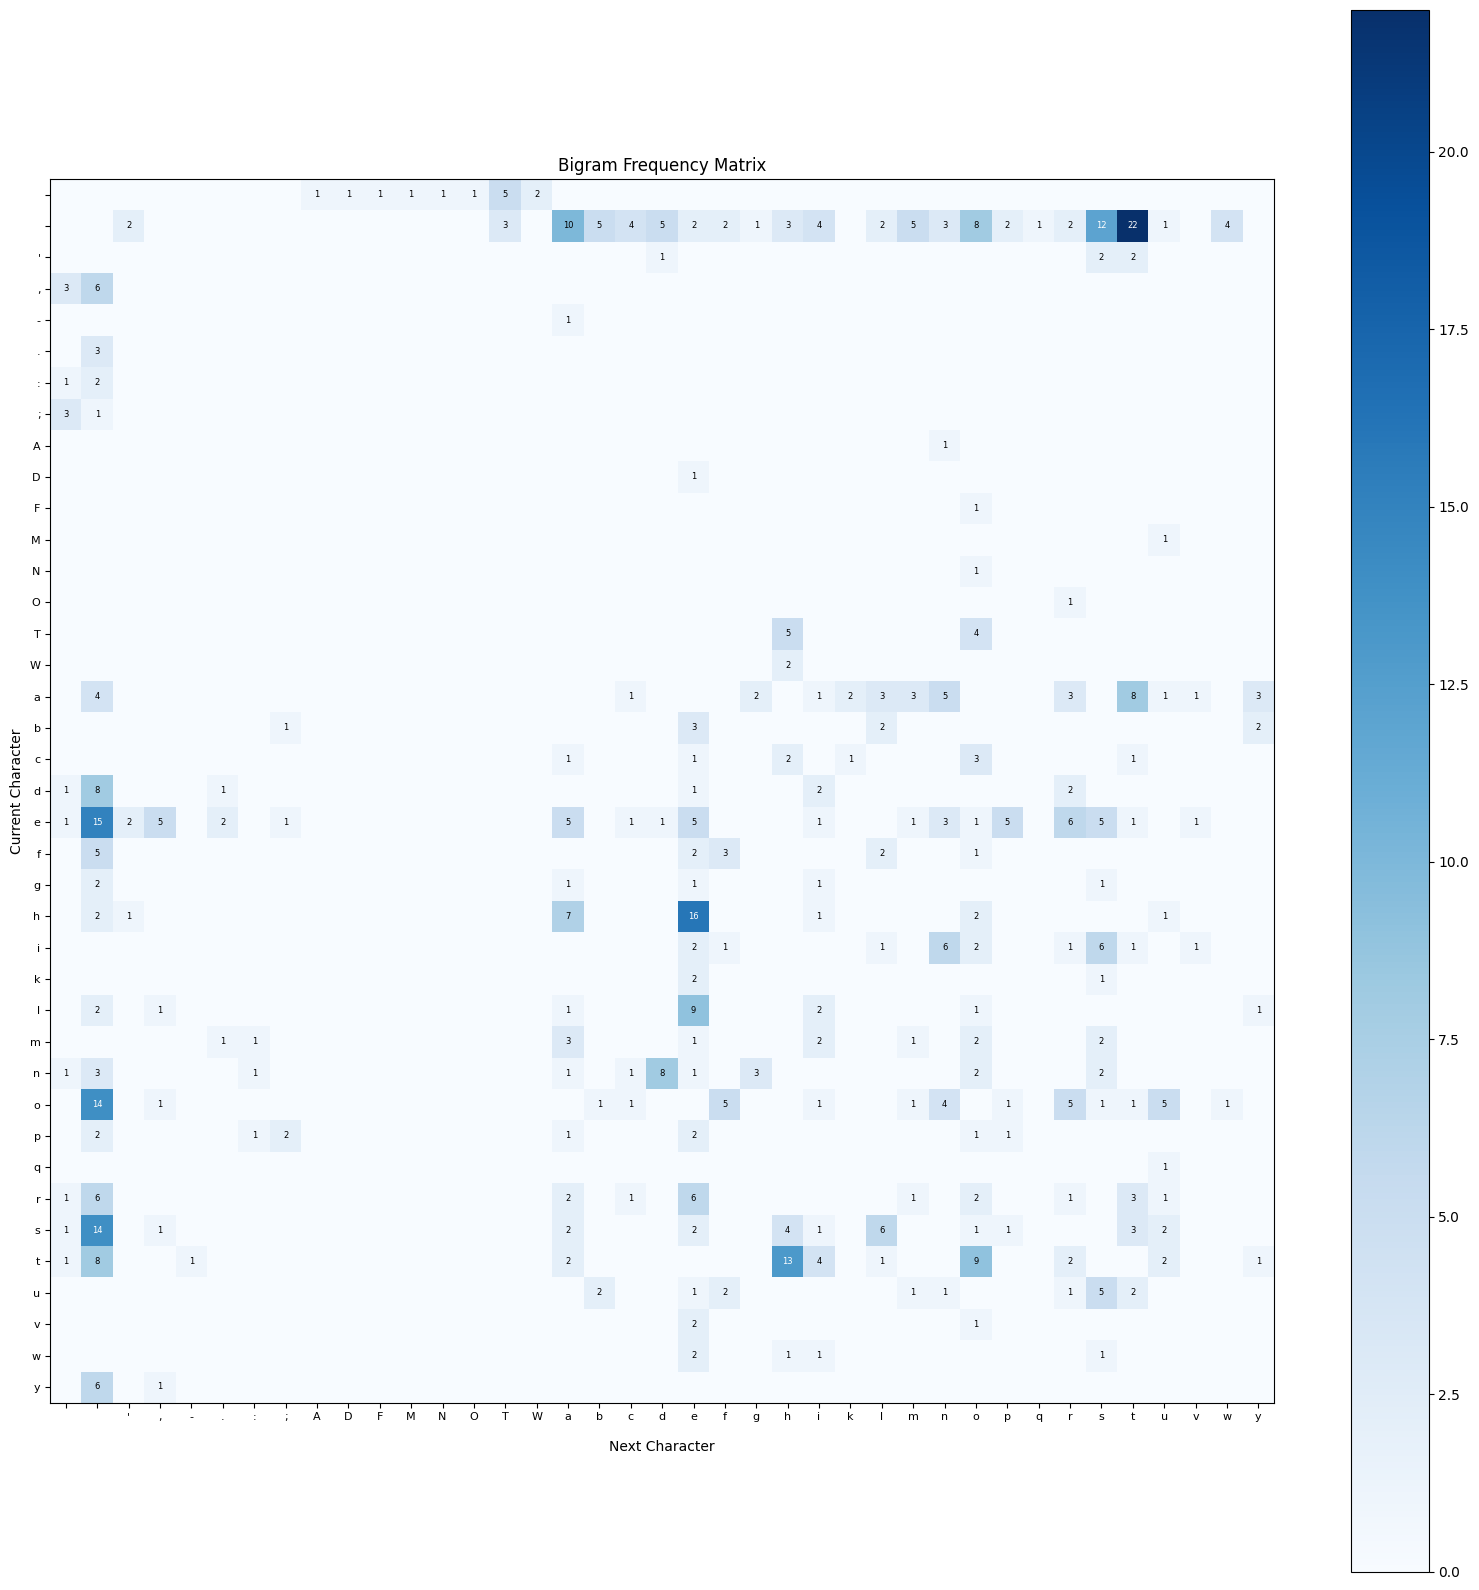

In [7]:
# Visualize the bigram frequency matrix
fig, ax = plt.subplots(figsize=(16, 16))
im = ax.imshow(bigram_counts.numpy(), cmap='Blues')

ax.set_xticks(range(vocab_size))
ax.set_yticks(range(vocab_size))
ax.set_xticklabels(chars, fontsize=8)
ax.set_yticklabels(chars, fontsize=8)
ax.set_xlabel('Next Character')
ax.set_ylabel('Current Character')
ax.set_title('Bigram Frequency Matrix')

# Add count values to cells
for i in range(vocab_size):
    for j in range(vocab_size):
        count = bigram_counts[i, j].item()
        if count > 0:
            ax.text(j, i, str(count), ha='center', va='center', fontsize=6,
                   color='white' if count > bigram_counts.max().item()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [8]:
# Convert counts to probabilities (normalize each row)
# Add smoothing to avoid zero probabilities
bigram_probs = (bigram_counts.float() + 1)  # Laplace smoothing
bigram_probs = bigram_probs / bigram_probs.sum(dim=1, keepdim=True)

# Verify: each row should sum to 1.0
print(f'Row sums (should all be ~1.0): {bigram_probs.sum(dim=1)[:5]}')

# What characters most likely follow 'T'?
t_idx = char_to_idx['T']
probs = bigram_probs[t_idx]
top_indices = torch.argsort(probs, descending=True)[:5]

print(f"\nTop 5 characters following 'T':")
for idx in top_indices:
    print(f"  '{idx_to_char[idx.item()]}' -> {probs[idx].item():.3f}")

Row sums (should all be ~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Top 5 characters following 'T':
  'h' -> 0.125
  'o' -> 0.104
  '
' -> 0.021
  'y' -> 0.021
  '-' -> 0.021


In [10]:
# Generate text using our bigram model!

def generate_bigram(start_char, length=200):
    """Generate text using bigram probabilities."""
    result = [start_char]
    current_idx = char_to_idx[start_char]
    
    for _ in range(length):
        # Get probability distribution for next character
        probs = bigram_probs[current_idx]
        # Sample from the distribution
        next_idx = torch.multinomial(probs, num_samples=1).item()
        result.append(idx_to_char[next_idx])
        current_idx = next_idx
    
    return ''.join(result)

print("=== Bigram Model Output ===")
print(generate_bigram('T', 300))

=== Bigram Model Output ===
Tmrkks dm;,ingf s themWfFyFrFkli o,Wocgkbb;:AWsios,ndbT:M;.sliedMFcfTomalOis
:OtNue'ocwly
DmMFo ue.wa
the

bfylamWykTOdMNwqqbh aN:k
TliOrmAducaAODncDe TainTmyusFa aiofenfk:
hMpfrcrrrtd  weokbeskNq tmuvTg;,
A, nTh,rTD,a;AcFgg'WaqeOpqle bgTAFbhe sy vvyNohiee,Wro s. ,Wv.-ee:
qydre t qActrul wTkeee kFep,


### Observations

The bigram model produces mostly **gibberish** — but notice:
- It picks up some common letter patterns (e.g., `th`, `he`, `in`)
- Spaces appear in roughly the right places
- It has no concept of words, grammar, or meaning

**Why is it so bad?** Because it only looks at ONE previous character. Real language has long-range dependencies. The word at position 50 might depend on a word at position 5.

This is exactly what neural networks — and ultimately Transformers — solve.

## 5. From Counting to Learning: Neural Bigram Model

Instead of counting bigrams manually, let's train a **neural network** to learn the same thing.

Why? Because this same architecture scales up to become GPT.

### The Neural Network Approach

1. **Input**: One-hot encoded current character (vector of size `vocab_size`)
2. **Weights**: A learnable matrix $W$ of shape `(vocab_size, vocab_size)`
3. **Output**: Logits (unnormalized scores) for next character
4. **Prediction**: Apply softmax to get probabilities

$$\text{logits} = x \cdot W$$
$$P(\text{next}) = \text{softmax}(\text{logits})$$

In [11]:
# Prepare training data
# X = current character, Y = next character

data = torch.tensor(encode(text), dtype=torch.long)
X = data[:-1]  # all characters except last
Y = data[1:]   # all characters except first (shifted by 1)

print(f'Training examples: {len(X)}')
print(f'\nFirst 10 examples:')
for i in range(10):
    print(f'  "{idx_to_char[X[i].item()]}" -> "{idx_to_char[Y[i].item()]}"')

Training examples: 604

First 10 examples:
  "T" -> "o"
  "o" -> " "
  " " -> "b"
  "b" -> "e"
  "e" -> ","
  "," -> " "
  " " -> "o"
  "o" -> "r"
  "r" -> " "
  " " -> "n"


In [12]:
# Define our neural bigram model

class NeuralBigram(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # An embedding table: each character gets a row of learnable weights
        # This is equivalent to one-hot encoding + linear layer
        self.embedding = nn.Embedding(vocab_size, vocab_size)
    
    def forward(self, x):
        # x shape: (batch_size,)
        # output shape: (batch_size, vocab_size) — logits for next character
        logits = self.embedding(x)
        return logits
    
    def generate(self, start_idx, max_length=200):
        """Generate text autoregressively."""
        result = [start_idx]
        current = torch.tensor([start_idx])
        
        for _ in range(max_length):
            logits = self.forward(current)
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1).squeeze()
            result.append(next_idx.item())
            current = next_idx.unsqueeze(0)
        
        return result

model = NeuralBigram(vocab_size)
print(f'Model parameters: {sum(p.numel() for p in model.parameters())}')
print(f'(That\'s a {vocab_size}x{vocab_size} = {vocab_size**2} parameter embedding matrix)')

Model parameters: 1521
(That's a 39x39 = 1521 parameter embedding matrix)


### Loss Function: Cross-Entropy

How do we measure how good our model's predictions are?

We use **cross-entropy loss**, which measures how different the model's predicted distribution is from the true distribution:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid x_i)$$

- If the model assigns **high probability** to the correct next character → **low loss**
- If the model assigns **low probability** to the correct next character → **high loss**

This is the SAME loss function used to train GPT-4, LLaMA, and every other LLM.

In [13]:
# Before training: check initial loss
# With random weights and vocab_size classes, expected loss = -ln(1/vocab_size)

logits = model(X)
loss = F.cross_entropy(logits, Y)
expected_loss = -torch.log(torch.tensor(1.0 / vocab_size))

print(f'Initial loss: {loss.item():.4f}')
print(f'Expected random loss: {expected_loss.item():.4f}')
print(f'(These should be close — the model is random right now)')

Initial loss: 4.2133
Expected random loss: 3.6636
(These should be close — the model is random right now)


In [14]:
# Train the model!

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []

for epoch in range(200):
    # Forward pass
    logits = model(X)
    loss = F.cross_entropy(logits, Y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 40 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f}')

print(f'\nFinal loss: {losses[-1]:.4f} (started at {losses[0]:.4f})')

Epoch  40 | Loss: 3.6612
Epoch  80 | Loss: 3.2100
Epoch 120 | Loss: 2.8684
Epoch 160 | Loss: 2.6149
Epoch 200 | Loss: 2.4309

Final loss: 2.4309 (started at 4.2133)


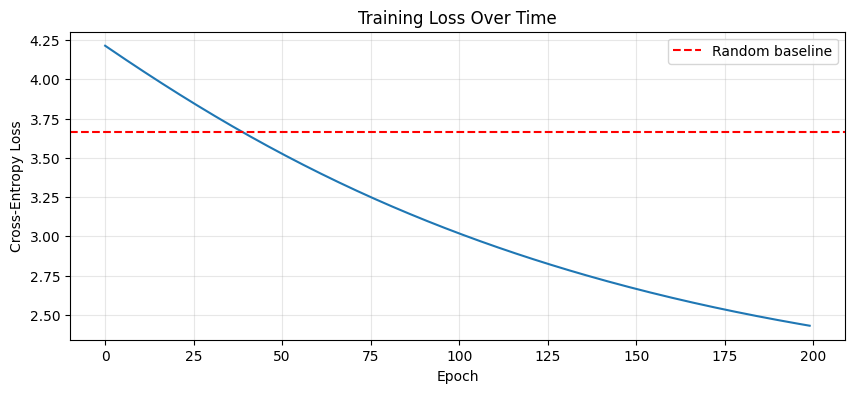

In [15]:
# Plot the training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Over Time')
plt.axhline(y=expected_loss.item(), color='r', linestyle='--', label='Random baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Generate text with the trained neural bigram model
generated_indices = model.generate(char_to_idx['T'], max_length=300)
generated_text = decode(generated_indices)

print("=== Neural Bigram Model Output ===")
print(generated_text)

=== Neural Bigram Model Output ===
Thd. thetah-l tnAslo t tuffisl,F
Toisen:
NoflieghofAD; isnerr
ForAnD; noFageeen;:
kDfDe
Whe ncis oh'd;drthatnwhuffem'dOravosfnewen,No.Wharen
An:rtop,W;vepth-akstlpe.che
Fk'scalctF ho.toqub;'du
OorAwDem-nD-Angsra blToqubeNore.coDeuneeWhe,nDm:logy th anl,shaf t.isNoWho mauWheduep;Angai tnvewhishw rc,
T


## 6. Scaling Up: MLP Language Model

The bigram model is limited because it only looks at **one character**. What if we look at the last **N characters**? That's a **context window**.

This is an **MLP (Multi-Layer Perceptron) language model**, similar to what Bengio et al. proposed in 2003.

### What Is a Context Window?

A context window is just a **sliding chunk of text** the model gets to read before making its prediction. Think of it like looking through a small window that only shows the last few characters:

```
Full text: "To be, or not to be"

Context window size = 8:

  Step 1:  [To be, o] → predict "r"
  Step 2:  [o be, or] → predict " "
  Step 3:  [ be, or ] → predict "n"
  Step 4:  [be, or n] → predict "o"
  ...
```

The window **slides forward one character at a time**. At each step, the model only sees what's inside the window and must predict the very next character after it.

**Why does this matter?** The bigram model's window size was 1 — it could only see one character. With a window of 8, the model sees enough to learn patterns like `"the "`, `"tion"`, `"to be"`. Bigger window → more context → better predictions.

### What Are Logits?

You'll see the word **logits** a lot. A logit is just a **raw score** — an unnormalized number that the neural network outputs for each possible next character.

For example, if our vocabulary is `[a, b, c, d, e]`, the model might output logits like:

```
logits = [2.1, -0.5, 0.3, 5.7, 1.2]
```

These numbers are **not** probabilities yet — they can be negative and don't sum to 1. To convert them into probabilities, we apply the **softmax** function:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

```
logits       = [  2.1,   -0.5,   0.3,    5.7,    1.2  ]
                  ↓       ↓      ↓       ↓       ↓
probabilities = [ 0.026,  0.002, 0.004,  0.952,  0.016 ]
                                          ↑
                             Highest logit → highest probability
                             Model predicts "d" is most likely
```

The model then **samples** from this probability distribution to pick the next character (or picks the highest one if you want deterministic output).

### The MLP Architecture (Step by Step)

Here's what happens inside the model, broken into clear steps:

```
INPUT: "To be, o"  (8 characters)
  │
  ▼ Step 1: ENCODE — convert each character to its integer ID
  [19, 40, 1, 28, 30, 7, 1, 40]     (8 integers)
  │
  ▼ Step 2: EMBED — look up a learned vector for each integer
  Each integer → a vector of 16 numbers (the "embedding")
  Shape goes from (8,) to (8, 16) — eight vectors of size 16
  │
  ▼ Step 3: FLATTEN — concatenate all 8 embedding vectors into one long vector
  (8, 16) → (128,)    — one flat vector of 128 numbers
  │
  ▼ Step 4: HIDDEN LAYERS — multiply by weight matrices + apply ReLU
  (128,) → Linear → ReLU → (128,) → Linear → ReLU → (128,)
  │
  ▼ Step 5: OUTPUT — final linear layer produces one score per character
  (128,) → Linear → (vocab_size,)    — one logit per possible next character
  │
  ▼ Step 6: SOFTMAX — convert logits to probabilities
  (vocab_size,) → softmax → (vocab_size,) — probabilities that sum to 1
  │
  ▼ Step 7: SAMPLE — randomly pick next character based on probabilities
  → "r" 
```

The neural network's job is to learn the **embedding vectors** (Step 2) and the **weight matrices** in the hidden layers (Steps 4–5) so that it produces high logits for characters that actually follow the given context.

In [23]:
# Prepare data with context windows

context_length = 8  # Look at the last 8 characters
embedding_dim = 16  # Each character gets a 16-dimensional embedding

# Build training examples
def build_dataset(text, context_length):
    X, Y = [], []
    encoded = encode(text)
    
    for i in range(len(encoded) - context_length):
        context = encoded[i:i + context_length]
        target = encoded[i + context_length]
        X.append(context)
        Y.append(target)
    
    return torch.tensor(X), torch.tensor(Y)

X_train, Y_train = build_dataset(text, context_length)
print(f'Training examples: {X_train.shape[0]}')
print(f'Input shape: {X_train.shape}  (batch_size, context_length)')
print(f'Target shape: {Y_train.shape}')

# Show some examples
print(f'\nExample contexts and targets:')
for i in range(5):
    context = decode(X_train[i].tolist())
    target = idx_to_char[Y_train[i].item()]
    print(f'  "{context}" -> "{target}"')

Training examples: 597
Input shape: torch.Size([597, 8])  (batch_size, context_length)
Target shape: torch.Size([597])

Example contexts and targets:
  "To be, o" -> "r"
  "o be, or" -> " "
  " be, or " -> "n"
  "be, or n" -> "o"
  "e, or no" -> "t"


In [24]:
# Define the MLP language model

class MLPLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_length, hidden_dim=128):
        super().__init__()
        self.context_length = context_length
        
        # EMBEDDING TABLE: a big lookup table with one row per character.
        # Each row is a vector of `embedding_dim` numbers that the model
        # will learn during training. Initially these are random.
        # Shape: (vocab_size, embedding_dim) — e.g. (45, 16)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # MLP LAYERS: a stack of linear transformations with ReLU activations.
        # This is where the model learns PATTERNS in the context.
        # Input size = embedding_dim * context_length because we concatenate all embeddings.
        self.mlp = nn.Sequential(
            # Layer 1: (128 inputs → 128 outputs) + ReLU activation
            nn.Linear(embedding_dim * context_length, hidden_dim),
            nn.ReLU(),   # ReLU(x) = max(0, x) — adds non-linearity so the model can learn complex patterns
            # Layer 2: (128 → 128) + ReLU
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            # Output layer: (128 → vocab_size) — produces one logit per possible next character
            nn.Linear(hidden_dim, vocab_size)
        )
    
    def forward(self, x):
        # x shape: (batch, context_length) — e.g. (batch, 8)
        # Each value in x is a character ID like 19 for 'T'
        
        # STEP 1: Look up embeddings for each character in the context
        emb = self.embedding(x)  # (batch, context_length, embedding_dim) e.g. (batch, 8, 16)
        
        # STEP 2: Flatten — concatenate all embeddings into one long vector
        # This combines all the context information into a single vector
        emb = emb.view(x.shape[0], -1)  # (batch, context_length * embedding_dim) e.g. (batch, 128)
        
        # STEP 3: Pass through the MLP to get logits (raw scores for each next character)
        logits = self.mlp(emb)  # (batch, vocab_size) e.g. (batch, 45)
        
        return logits
    
    def generate(self, start_text, max_length=200):
        """Generate text one character at a time (autoregressively)."""
        encoded = encode(start_text)
        # Pad with zeros if start_text is shorter than context_length
        while len(encoded) < self.context_length:
            encoded = [0] + encoded
        
        result = list(start_text)
        context = encoded[-self.context_length:]  # Take last context_length characters
        
        for _ in range(max_length):
            # Feed the current context window into the model
            x = torch.tensor([context])
            logits = self.forward(x)                         # Get raw scores
            probs = F.softmax(logits, dim=-1)                # Convert to probabilities
            next_idx = torch.multinomial(probs, num_samples=1).item()  # Sample next char
            result.append(idx_to_char[next_idx])
            
            # SLIDE THE WINDOW: drop the oldest character, append the new one
            # [a, b, c, d, e, f, g, h] + new → [b, c, d, e, f, g, h, new]
            context = context[1:] + [next_idx]
        
        return ''.join(result)

mlp_model = MLPLanguageModel(vocab_size, embedding_dim, context_length)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f'MLP Model parameters: {total_params:,}')
print(f'\nArchitecture:')
print(mlp_model)

MLP Model parameters: 38,679

Architecture:
MLPLanguageModel(
  (embedding): Embedding(39, 16)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=39, bias=True)
  )
)


### Walkthrough: Tracing a Single Example Through the MLP

Let's take one training example and watch exactly what happens at each step — with real numbers. This is the best way to understand what the model is actually doing.

In [25]:
# === STEP-BY-STEP WALKTHROUGH ===
# Let's trace exactly what happens when the model processes one example

# Pick one training example
example_idx = 0
context_ids = X_train[example_idx]   # The 8 character IDs
target_id = Y_train[example_idx]     # The correct next character

context_text = decode(context_ids.tolist())
target_char = idx_to_char[target_id.item()]
print(f'Context: "{context_text}"')
print(f'Target (correct next character): "{target_char}"')
print(f'Context as integer IDs: {context_ids.tolist()}')
print()

# --- STEP 1: EMBEDDING LOOKUP ---
# Each character ID gets looked up in the embedding table.
# The embedding table has one row per character, each row has 16 numbers.

with torch.no_grad():
    emb = mlp_model.embedding(context_ids.unsqueeze(0))  # Add batch dimension

print(f'STEP 1 — Embedding lookup:')
print(f'  Input shape:  {context_ids.unsqueeze(0).shape}  →  (1 example, {context_length} characters)')
print(f'  Output shape: {emb.shape}  →  (1 example, {context_length} characters, {embedding_dim} numbers each)')
print()

# Show what the embedding looks like for the first character
first_char = idx_to_char[context_ids[0].item()]
print(f'  Embedding for "{first_char}" (char ID {context_ids[0].item()}):')
print(f'  {emb[0, 0, :6].numpy().round(3)}...  (showing first 6 of {embedding_dim} values)')
print()

# --- STEP 2: FLATTEN ---
# Concatenate all 8 embedding vectors into one long vector
flat = emb.view(1, -1)
print(f'STEP 2 — Flatten (concatenate all embeddings):')
print(f'  Before: {emb.shape}  →  8 separate vectors of size 16')
print(f'  After:  {flat.shape}  →  one vector of size {context_length} × {embedding_dim} = {context_length * embedding_dim}')
print()

# --- STEP 3: PASS THROUGH MLP ---
# The flattened vector goes through the hidden layers
with torch.no_grad():
    logits = mlp_model(context_ids.unsqueeze(0))

print(f'STEP 3 — MLP layers produce logits:')
print(f'  Output shape: {logits.shape}  →  (1 example, {vocab_size} possible next characters)')
print(f'  Raw logits (one score per character):')
print(f'  {logits[0, :10].numpy().round(3)}...  (showing first 10 of {vocab_size})')
print()

# --- STEP 4: SOFTMAX → PROBABILITIES ---
probs = F.softmax(logits, dim=-1)
print(f'STEP 4 — Softmax converts logits to probabilities:')
print(f'  Probabilities sum to: {probs.sum().item():.4f} (should be 1.0)')
print()

# Show top 5 predictions
top_probs, top_indices = probs[0].topk(5)
print(f'  Top 5 predictions for next character after "{context_text}":')
for p, idx in zip(top_probs, top_indices):
    marker = " ← CORRECT!" if idx_to_char[idx.item()] == target_char else ""
    print(f'    "{idx_to_char[idx.item()]}" → {p.item():.3f} ({p.item()*100:.1f}%){marker}')
print()

# --- STEP 5: SAMPLE ---
print(f'STEP 5 — Sample from the probability distribution:')
print(f'  The model randomly picks a character based on these probabilities.')
print(f'  Higher probability = more likely to be picked.')
print(f'  This randomness is why you get different outputs each time!')

Context: "To be, o"
Target (correct next character): "r"
Context as integer IDs: [14, 29, 1, 17, 20, 3, 1, 29]

STEP 1 — Embedding lookup:
  Input shape:  torch.Size([1, 8])  →  (1 example, 8 characters)
  Output shape: torch.Size([1, 8, 16])  →  (1 example, 8 characters, 16 numbers each)

  Embedding for "T" (char ID 14):
  [ 1.621  0.199 -0.06   1.471 -0.325  1.065]...  (showing first 6 of 16 values)

STEP 2 — Flatten (concatenate all embeddings):
  Before: torch.Size([1, 8, 16])  →  8 separate vectors of size 16
  After:  torch.Size([1, 128])  →  one vector of size 8 × 16 = 128

STEP 3 — MLP layers produce logits:
  Output shape: torch.Size([1, 39])  →  (1 example, 39 possible next characters)
  Raw logits (one score per character):
  [-0.161  0.046 -0.07  -0.052  0.219 -0.083  0.08   0.107 -0.181  0.01 ]...  (showing first 10 of 39)

STEP 4 — Softmax converts logits to probabilities:
  Probabilities sum to: 1.0000 (should be 1.0)

  Top 5 predictions for next character after "To be

### Visualizing Logits → Probabilities

Let's see what the softmax function actually does to the raw logits.

In [ ]:
# Visualize how logits become probabilities

with torch.no_grad():
    logits = mlp_model(X_train[:1])
    probs = F.softmax(logits, dim=-1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Raw logits
bars1 = ax1.bar(range(vocab_size), logits[0].numpy(), color='steelblue', alpha=0.7)
ax1.set_xticks(range(vocab_size))
ax1.set_xticklabels(chars, fontsize=8)
ax1.set_ylabel('Logit (raw score)')
ax1.set_title(f'Raw Logits — unnormalized scores (can be negative, don\'t sum to 1)')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Highlight the correct answer
target = Y_train[0].item()
bars1[target].set_color('red')
bars1[target].set_alpha(1.0)
ax1.annotate(f'correct: "{idx_to_char[target]}"', xy=(target, logits[0, target].item()), 
             xytext=(target + 3, logits[0].max().item()),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)

# Plot 2: Probabilities after softmax
bars2 = ax2.bar(range(vocab_size), probs[0].numpy(), color='seagreen', alpha=0.7)
ax2.set_xticks(range(vocab_size))
ax2.set_xticklabels(chars, fontsize=8)
ax2.set_ylabel('Probability')
ax2.set_title(f'After Softmax — valid probabilities (all positive, sum to 1.0)')
ax2.grid(True, alpha=0.3, axis='y')

bars2[target].set_color('red')
bars2[target].set_alpha(1.0)

plt.tight_layout()
plt.show()

context_text = decode(X_train[0].tolist())
print(f'Context: "{context_text}" → trying to predict: "{idx_to_char[target]}"')
print(f'Sum of all probabilities: {probs[0].sum().item():.4f}')

### Visualizing the Sliding Window

Let's watch how the context window slides through text during generation.

In [ ]:
# Show how the sliding window works during text generation

print("=== How the Sliding Window Generates Text ===")
print(f"Window size: {context_length} characters\n")

# Start with some text
start_text = "To be, o"
encoded = encode(start_text)
context = encoded[-context_length:]

print(f"Starting context: \"{start_text}\"\n")

# Generate 10 characters, showing the window at each step
generated = list(start_text)
for step in range(10):
    # Show current window
    window_text = decode(context)
    
    # Get prediction
    with torch.no_grad():
        x = torch.tensor([context])
        logits = mlp_model(x)
        probs = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1).item()
    
    next_char = idx_to_char[next_idx]
    prob = probs[0, next_idx].item()
    
    # Visual: show the window sliding
    print(f"  Step {step+1}: [{window_text}] → \"{next_char}\" (prob: {prob:.3f})")
    
    # Slide the window
    generated.append(next_char)
    context = context[1:] + [next_idx]  # Drop oldest, add newest

print(f"\n  Generated so far: \"{''.join(generated)}\"")
print(f"\n  Notice how the window drops the leftmost character and shifts right")
print(f"  each time a new character is generated!")

In [19]:
# Train the MLP model

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.003)
mlp_losses = []

for epoch in range(500):
    logits = mlp_model(X_train)
    loss = F.cross_entropy(logits, Y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    mlp_losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f}')

print(f'\nFinal loss: {mlp_losses[-1]:.4f}')

Epoch 100 | Loss: 0.0062
Epoch 200 | Loss: 0.0053
Epoch 300 | Loss: 0.0050
Epoch 400 | Loss: 0.0049
Epoch 500 | Loss: 0.0048

Final loss: 0.0048


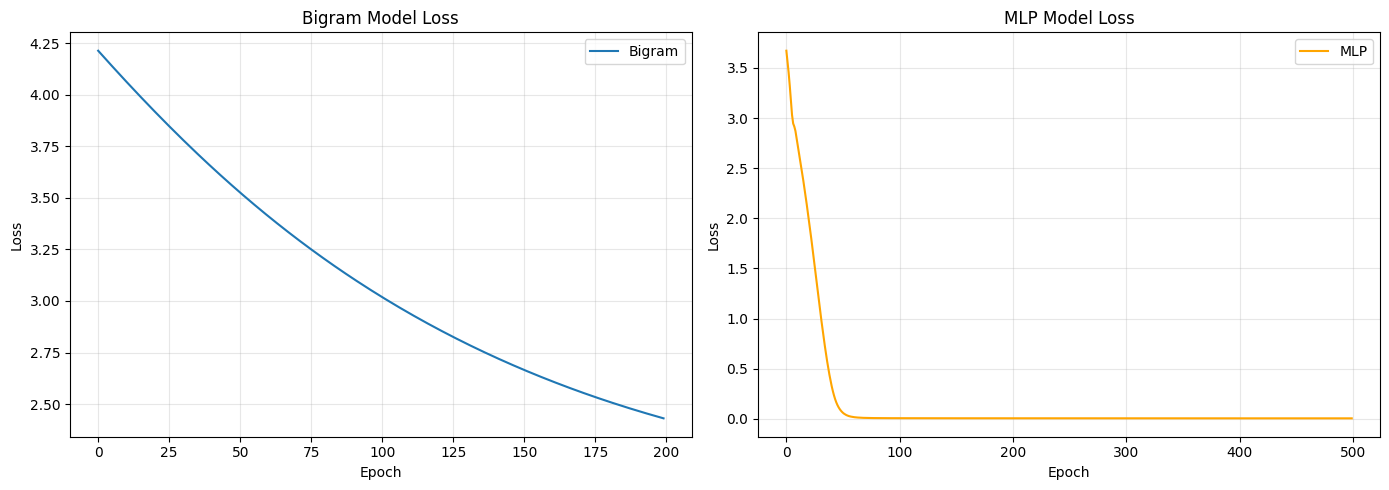

Final Bigram loss: 2.4309
Final MLP loss:    0.0048
MLP is 504.3x better (lower loss = better)


In [20]:
# Compare losses: Bigram vs MLP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses, label='Bigram')
ax1.set_title('Bigram Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mlp_losses, label='MLP', color='orange')
ax2.set_title('MLP Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Bigram loss: {losses[-1]:.4f}')
print(f'Final MLP loss:    {mlp_losses[-1]:.4f}')
print(f'MLP is {losses[-1] / mlp_losses[-1]:.1f}x better (lower loss = better)')

In [21]:
# Generate text with MLP model
print("=== MLP Language Model Output ===")
print(mlp_model.generate('To be', 300))

=== MLP Language Model Output ===
To be anslmea if the miepeub nh mhet ar spiep:
Thet tr sheem;
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles,
And by opposing end them. To die, to sleep;
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to, 'ti


## 7. Understanding What the Model Learned

Let's peek inside the model to understand what it learned.

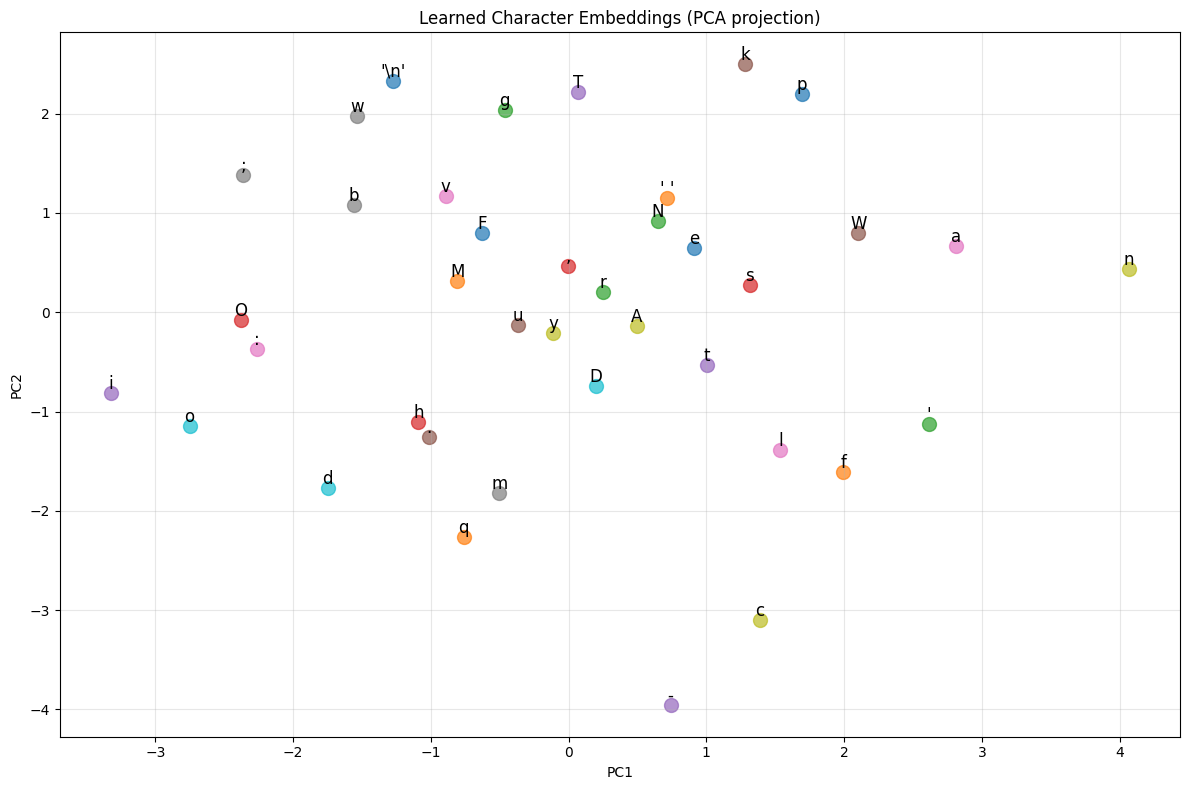

Notice: vowels tend to cluster together, consonants cluster together
The model DISCOVERED these categories from raw text — nobody told it about vowels!


In [22]:
# Visualize the learned character embeddings
# Use PCA to reduce dimensions for visualization

from sklearn.decomposition import PCA

embeddings = mlp_model.embedding.weight.detach().numpy()
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
for i, char in enumerate(chars):
    x, y = embeddings_2d[i]
    display_char = repr(char) if char in ' \n\t' else char
    plt.scatter(x, y, s=100, alpha=0.7)
    plt.annotate(display_char, (x, y), fontsize=12, ha='center', va='bottom')

plt.title('Learned Character Embeddings (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Notice: vowels tend to cluster together, consonants cluster together')
print('The model DISCOVERED these categories from raw text — nobody told it about vowels!')

## 8. The Limitations and the Path Forward

### What We've Built So Far

| Model | Context | Quality | Parameters |
|-------|---------|---------|------------|
| Bigram | 1 char | Gibberish | ~2,500 |
| MLP | 8 chars | Better patterns | ~20,000 |

### Key Limitations of the MLP Approach

1. **Fixed context window**: The model can only look at the last N characters. To handle longer contexts, the model gets huge.

2. **No parameter sharing**: The weights for position 1 and position 2 are completely separate. The model has to learn the same patterns independently for each position.

3. **Position-dependent**: The model treats `"cat"` differently depending on WHERE in the context window it appears.

### What's Next: The Transformer

The **Transformer architecture** (Vaswani et al., 2017) solves all of these problems with a mechanism called **self-attention**:

- **Dynamic context**: Each position can "attend" to any other position
- **Parameter sharing**: Same attention weights used at every position
- **Parallelizable**: Unlike RNNs, all positions computed simultaneously

We'll build a Transformer from scratch in **Notebook 3**.

## 9. Exercises

### Exercise 1: Trigram Model
Modify the counting-based model to use **trigrams** (two previous characters instead of one). How much does generation quality improve?

In [ ]:
# EXERCISE 1: Build a trigram counting model
# Hint: Instead of a 2D count matrix, you'll need to think about
# how to represent counts for (char[t-2], char[t-1]) -> char[t]

# Your code here

### Exercise 2: Temperature Sampling

**Temperature** controls how "creative" vs "conservative" the model's outputs are:

$$P(x_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- $T = 1.0$: Normal sampling
- $T < 1.0$: More deterministic (picks high-probability tokens)
- $T > 1.0$: More random (flattens the distribution)

Implement temperature sampling for the MLP model.

In [ ]:
# EXERCISE 2: Implement temperature sampling
# Modify the generate function to accept a temperature parameter

def generate_with_temperature(model, start_text, max_length=200, temperature=1.0):
    # Your code here
    pass

# Try different temperatures: 0.5, 1.0, 1.5, 2.0

### Exercise 3: Larger Dataset

Download a larger text dataset and retrain the MLP model. Suggestions:
- Full Shakespeare (~1MB): `https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt`
- Try different `context_length` values (4, 8, 16, 32)
- Try different `embedding_dim` values
- How do these hyperparameters affect quality?

In [ ]:
# EXERCISE 3: Larger dataset training
# Your code here

## 10. Key Takeaways

1. **Language models predict the next token** given previous tokens — this is ALL they do
2. **Text must be converted to numbers** before a neural network can process it
3. **Cross-entropy loss** measures how well the model's predicted distribution matches the true next token
4. **More context = better predictions** — a bigram model is terrible because it only sees 1 character
5. **Embeddings are learned representations** — the model discovers structure (like vowels vs consonants) automatically
6. **MLP models are limited** by fixed context windows — Transformers solve this

### What's Coming Next
**Notebook 2: Tokenization and Embeddings** — We'll learn how real LLMs convert text to tokens (BPE), build our own tokenizer, and understand word embeddings in depth.